# Concurrence and CHSH Geometry in X-Theta V2

This notebook explores the relationship between entanglement measures (Concurrence), the maximum possible Bell violation ($S_{max}$), and fixed-basis CHSH projections ($S_{XY}, S_{XZ}$).

## Theory Summary

- **Concurrence**: $C(\Phi) = |\cos(2\Phi)|$
- **Horodecki Maximum**: $S_{max} = 2\sqrt{1 + C^2} = 2\sqrt{1 + \cos^2(2\Phi)}$
- **XY Projection**: $S_{XY} = 2\sqrt{2}|\cos(2\Phi)| = 2\sqrt{2} C$
- **XZ Projection**: $S_{XZ} = 2\sqrt{2}\cos^2(\Phi)$
- **Anisotropy Invariant**: $R_\Theta = 2\sin^2(2\Phi) = 2(1 - C^2)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xtheta.quantum.engine import (
    compute_chsh_max, compute_chsh_xy, compute_chsh_xz, 
    compute_concurrence_from_phi, evolve_state, compute_correlation_tensor,
    compute_invariants
)

phi_range = np.linspace(0, np.pi/2, 100)

c_vals = []
s_max_vals = []
s_xy_vals = []
s_xz_vals = []
r_theta_vals = []

for phi in phi_range:
    psi = evolve_state(phi)
    T = compute_correlation_tensor(psi)
    
    c_vals.append(compute_concurrence_from_phi(phi))
    s_max_vals.append(compute_chsh_max(T))
    s_xy_vals.append(compute_chsh_xy(phi))
    s_xz_vals.append(compute_chsh_xz(phi))
    _, r_theta = compute_invariants(T)
    r_theta_vals.append(r_theta)

## Visualizing the Quantum Diagnostics

<>:4: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:5: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:16: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:4: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:5: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:16: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will no

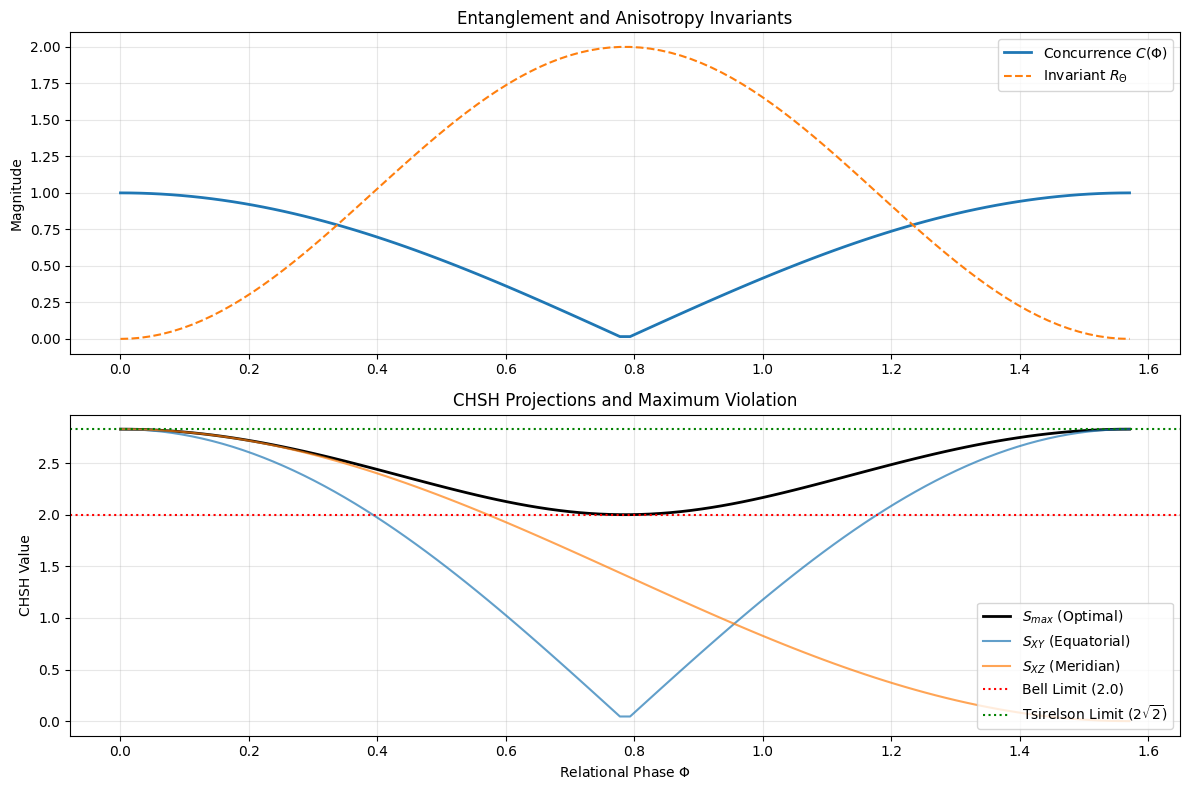

In [3]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(phi_range, c_vals, label="Concurrence $C(\Phi)$", linewidth=2)
plt.plot(phi_range, r_theta_vals, label="Invariant $R_\Theta$", linestyle='--')
plt.ylabel("Magnitude")
plt.title("Entanglement and Anisotropy Invariants")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(phi_range, s_max_vals, label="$S_{max}$ (Optimal)", linewidth=2, color='black')
plt.plot(phi_range, s_xy_vals, label="$S_{XY}$ (Equatorial)", alpha=0.7)
plt.plot(phi_range, s_xz_vals, label="$S_{XZ}$ (Meridian)", alpha=0.7)
plt.axhline(y=2.0, color='r', linestyle=':', label="Bell Limit (2.0)")
plt.axhline(y=2*np.sqrt(2), color='g', linestyle=':', label="Tsirelson Limit ($2\sqrt{2}$)")
plt.ylabel("CHSH Value")
plt.xlabel("Relational Phase $\Phi$")
plt.title("CHSH Projections and Maximum Violation")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('concurrence_chsh_curves.png')
plt.show()

## Scientific Conclusion

X-Theta V2 predicts that different CHSH geometries are projections of the same anisotropic correlation tensor. 

1. The basis-independent relation is $S_{max} = 2\sqrt{1 + C^2}$.
2. The anisotropy invariant is $R_\Theta = 2(1 - C^2)$.

This demonstrates that the relational phase doesn't just rotate the measurement basis but changes the underlying entanglement structure of the state as seen in any fixed laboratory frame.